In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage
from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re

In [2]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250424_*',
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250425_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
        #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 108 directories


In [3]:
folder_info = ori_results

In [4]:
r1_ori_aide = filter_folder_info(folder_info, [
   ('levels', 125),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'aide'),
   ('model', 'deepseek-r1'),
   ('n_initial_hypotheses', 3),
   ('n_hypotheses', 1),
   ('debug_prob', 0.5),
])
r1_bo3 = filter_folder_info(folder_info, [
   ('levels', 125),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'bon'),
   ('model', 'deepseek-r1'),
   ('n_initial_hypotheses', 3),
   ('n_hypotheses', 3),
])
o3_ori_aide = filter_folder_info(folder_info, [
   ('levels', 125),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'aide'),
   ('model', 'o3-mini'),
   ('n_initial_hypotheses', 3),
   ('n_hypotheses', 1),
   ('debug_prob', 0.5),
])
o3_bo3 = filter_folder_info(folder_info, [
   ('levels', 125),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'bon'),
   ('model', 'o3-mini'),
   ('n_initial_hypotheses', 3),
   ('n_hypotheses', 3),
])

In [5]:
len(r1_ori_aide), len(r1_bo3), len(o3_ori_aide), len(o3_bo3)

(18, 18, 18, 18)

In [6]:
r1_ori_aide = process_metrics(r1_ori_aide)
r1_bo3 = process_metrics(r1_bo3)
o3_ori_aide = process_metrics(o3_ori_aide)
o3_bo3 = process_metrics(o3_bo3)

In [7]:
r1_aide_res = convert_to_dict(r1_ori_aide)
r1_bo3_res = convert_to_dict(r1_bo3)
o3_ori_aide_res = convert_to_dict(o3_ori_aide)
o3_bo3_res = convert_to_dict(o3_bo3)

In [8]:
r1_aide_gap = compute_gap_in_percentage(r1_aide_res)
r1_bo3_gap = compute_gap_in_percentage(r1_bo3_res)
o3_aide_gap = compute_gap_in_percentage(o3_ori_aide_res)
o3_bo3_gap = compute_gap_in_percentage(o3_bo3_res)

In [9]:
r1_aide_gap = {str(k): v for k, v in r1_aide_gap.items()}
r1_bo3_gap = {str(k): v for k, v in r1_bo3_gap.items()}
o3_aide_gap = {str(k): v for k, v in o3_aide_gap.items()}
o3_bo3_gap = {str(k): v for k, v in o3_bo3_gap.items()}

In [10]:
del r1_aide_gap['6']
del r1_bo3_gap['6']
del o3_aide_gap['6']
del o3_bo3_gap['6']

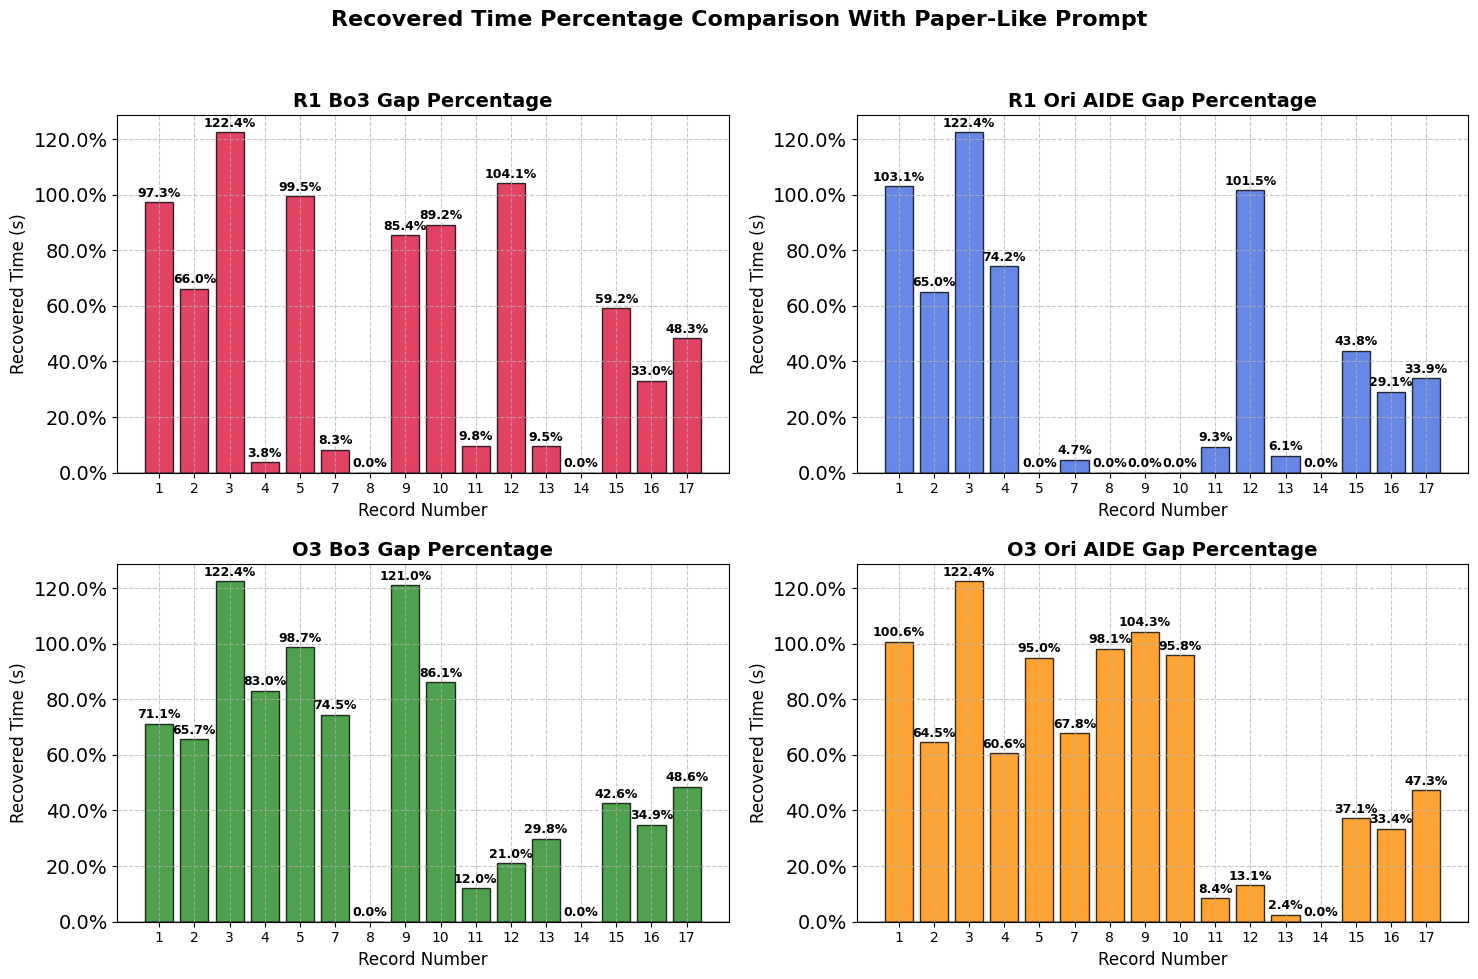

In [11]:
# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (r1_bo3_gap, "R1 Bo3 Gap Percentage", 'crimson'),
    (r1_aide_gap, "R1 Ori AIDE Gap Percentage", 'royalblue'),
    (o3_bo3_gap, "O3 Bo3 Gap Percentage", 'forestgreen'),
    (o3_aide_gap, "O3 Ori AIDE Gap Percentage", 'darkorange'),
]

plot_gap_comparison(data_dicts, figsize=(15, 10))
plt.show()